In [3]:
import os
os.environ['KAGGLE_API_TOKEN'] = 'KGAT_06bb26359433bffbaf435119a4e5386e'  # use your NEW token after revoking this one

!pip install -q kaggle
!kaggle datasets download -d wordsforthewise/lending-club
!unzip -q lending-club.zip -d data/

Dataset URL: https://www.kaggle.com/datasets/wordsforthewise/lending-club
License(s): CC0-1.0
100% 1.26G/1.26G [00:11<00:00, 116MB/s]



In [4]:
!ls -lh data/

total 619M
drwxr-xr-x 2 root root 4.0K Aug  2 06:40 accepted_2007_to_2018q4.csv
-rw-r--r-- 1 root root 375M Dec 17  2019 accepted_2007_to_2018Q4.csv.gz
drwxr-xr-x 2 root root 4.0K Aug  2 06:40 rejected_2007_to_2018q4.csv
-rw-r--r-- 1 root root 244M Dec 17  2019 rejected_2007_to_2018Q4.csv.gz


In [5]:
import pandas as pd

usecols = ['loan_amnt', 'term', 'int_rate', 'installment', 'grade', 'sub_grade',
           'emp_length', 'home_ownership', 'annual_inc', 'purpose', 'dti',
           'delinq_2yrs', 'earliest_cr_line', 'fico_range_low', 'fico_range_high',
           'open_acc', 'pub_rec', 'revol_bal', 'revol_util', 'total_acc',
           'issue_d', 'loan_status']

df = pd.read_csv('data/accepted_2007_to_2018Q4.csv.gz', usecols=usecols, low_memory=False)
print(df.shape)
df.head()

(2260701, 22)


,loan_amnt,term,int_rate,installment,grade,sub_grade,emp_length,home_ownership,annual_inc,issue_d,...,dti,delinq_2yrs,earliest_cr_line,fico_range_low,fico_range_high,open_acc,pub_rec,revol_bal,revol_util,total_acc
0,3600.0,36 months,13.99,123.03,C,C4,10+ years,MORTGAGE,55000.0,Dec-2015,...,5.91,0.0,Aug-2003,675.0,679.0,7.0,0.0,2765.0,29.7,13.0
1,24700.0,36 months,11.99,820.28,C,C1,10+ years,MORTGAGE,65000.0,Dec-2015,...,16.06,1.0,Dec-1999,715.0,719.0,22.0,0.0,21470.0,19.2,38.0
2,20000.0,60 months,10.78,432.66,B,B4,10+ years,MORTGAGE,63000.0,Dec-2015,...,10.78,0.0,Aug-2000,695.0,699.0,6.0,0.0,7869.0,56.2,18.0
3,35000.0,60 months,14.85,829.90,C,C5,10+ years,MORTGAGE,110000.0,Dec-2015,...,17.06,0.0,Sep-2008,785.0,789.0,13.0,0.0,7802.0,11.6,17.0
4,10400.0,60 months,22.45,289.91,F,F1,3 years,MORTGAGE,104433.0,Dec-2015,...,25.37,1.0,Jun-1998,695.0,699.0,12.0,0.0,21929.0,64.5,35.0


In [6]:
print(df['loan_status'].value_counts())

loan_status
Fully Paid                                             1076751
Current                                                 878317
Charged Off                                             268559
Late (31-120 days)                                       21467
In Grace Period                                           8436
Late (16-30 days)                                         4349
Does not meet the credit policy. Status:Fully Paid        1988
Does not meet the credit policy. Status:Charged Off        761
Default                                                     40
Name: count, dtype: int64


In [7]:
bad_status = ['Charged Off', 'Default', 'Does not meet the credit policy. Status:Charged Off',
              'Late (31-120 days)']
good_status = ['Fully Paid', 'Does not meet the credit policy. Status:Fully Paid']

df = df[df['loan_status'].isin(bad_status + good_status)].copy()
df['default'] = df['loan_status'].isin(bad_status).astype(int)

print(df['default'].value_counts(normalize=True))

default
0    0.78765
1    0.21235
Name: proportion, dtype: float64


In [8]:
df.isnull().sum().sort_values(ascending=False) / len(df) * 100

,0
emp_length,5.870546
revol_util,0.067467
dti,0.029060
delinq_2yrs,0.002117
earliest_cr_line,0.002117
total_acc,0.002117
open_acc,0.002117
pub_rec,0.002117
annual_inc,0.000292
sub_grade,0.000000


In [9]:
# emp_length: keep missingness as information rather than guessing
df['emp_length'] = df['emp_length'].fillna('Missing')

# numeric fields with tiny missingness: median impute
for col in ['revol_util', 'dti', 'annual_inc', 'delinq_2yrs', 'total_acc', 'open_acc', 'pub_rec']:
    df[col] = df[col].fillna(df[col].median())

# earliest_cr_line: drop rows missing this (0.2%, negligible loss) since it needs date parsing
df = df.dropna(subset=['earliest_cr_line'])

In [10]:
df['issue_d'] = pd.to_datetime(df['issue_d'], format='%b-%Y')
df['earliest_cr_line'] = pd.to_datetime(df['earliest_cr_line'], format='%b-%Y')

df['credit_history_months'] = (
    (df['issue_d'] - df['earliest_cr_line']).dt.days / 30.44
)

In [11]:
df['term'] = df['term'].str.extract('(\d+)').astype(int)

emp_length_map = {
    '< 1 year': 0, '1 year': 1, '2 years': 2, '3 years': 3, '4 years': 4,
    '5 years': 5, '6 years': 6, '7 years': 7, '8 years': 8, '9 years': 9,
    '10+ years': 10, 'Missing': -1
}
df['emp_length_num'] = df['emp_length'].map(emp_length_map)

<>:1: SyntaxWarning: invalid escape sequence '\d'
<>:1: SyntaxWarning: invalid escape sequence '\d'
/tmp/ipykernel_1023/278896292.py:1: SyntaxWarning: invalid escape sequence '\d'
  df['term'] = df['term'].str.extract('(\d+)').astype(int)


In [12]:
df = df.sort_values('issue_d')
cutoff = df['issue_d'].quantile(0.8)

train = df[df['issue_d'] <= cutoff].copy()
test = df[df['issue_d'] > cutoff].copy()

print(f"Train: {train.shape}, Test: {test.shape}")
print(f"Train date range: {train['issue_d'].min()} to {train['issue_d'].max()}")
print(f"Test date range: {test['issue_d'].min()} to {test['issue_d'].max()}")

Train: (1108727, 25), Test: (260810, 25)
Train date range: 2007-06-01 00:00:00 to 2016-11-01 00:00:00
Test date range: 2016-12-01 00:00:00 to 2018-12-01 00:00:00


In [13]:
import numpy as np

def calc_woe_iv(df, feature, target, bins=10, is_categorical=False):
    df = df[[feature, target]].copy()

    if is_categorical:
        df['bin'] = df[feature].astype(str)
    else:
        df['bin'] = pd.qcut(df[feature], bins, duplicates='drop')

    grouped = df.groupby('bin', observed=True)[target].agg(['count', 'sum'])
    grouped.columns = ['total', 'bad']
    grouped['good'] = grouped['total'] - grouped['bad']

    grouped['pct_good'] = grouped['good'] / grouped['good'].sum()
    grouped['pct_bad'] = grouped['bad'] / grouped['bad'].sum()

    grouped['pct_good'] = grouped['pct_good'].replace(0, 0.0001)
    grouped['pct_bad'] = grouped['pct_bad'].replace(0, 0.0001)

    grouped['woe'] = np.log(grouped['pct_good'] / grouped['pct_bad'])
    grouped['iv'] = (grouped['pct_good'] - grouped['pct_bad']) * grouped['woe']

    return grouped, grouped['iv'].sum()

In [14]:
numeric_features = ['loan_amnt', 'term', 'int_rate', 'installment', 'annual_inc',
                     'dti', 'delinq_2yrs', 'open_acc', 'pub_rec', 'revol_util',
                     'total_acc', 'credit_history_months', 'emp_length_num']

categorical_features = ['grade', 'sub_grade', 'home_ownership', 'purpose']

iv_results = {}
woe_tables = {}

for feat in numeric_features:
    table, iv = calc_woe_iv(train, feat, 'default', bins=10, is_categorical=False)
    woe_tables[feat] = table
    iv_results[feat] = iv

for feat in categorical_features:
    table, iv = calc_woe_iv(train, feat, 'default', bins=None, is_categorical=True)
    woe_tables[feat] = table
    iv_results[feat] = iv

iv_summary = pd.Series(iv_results).sort_values(ascending=False)
print(iv_summary)

sub_grade                0.500798
grade                    0.466563
int_rate                 0.449064
dti                      0.075749
loan_amnt                0.033355
annual_inc               0.028635
installment              0.026261
home_ownership           0.025235
purpose                  0.019554
revol_util               0.019281
credit_history_months    0.009372
open_acc                 0.007622
emp_length_num           0.004627
delinq_2yrs              0.001759
pub_rec                  0.001434
total_acc                0.000611
term                     0.000000
dtype: float64


In [15]:
train['term'].value_counts()

,count
term,
36,840491
60,268236


In [17]:
table, iv = calc_woe_iv(train, 'term', 'default', bins=None, is_categorical=True)
woe_tables['term'] = table
iv_results['term'] = iv
print(iv)
print(table)

0.207385123434771
      total     bad    good  pct_good   pct_bad       woe        iv
bin                                                                
36   840491  131770  708721  0.799394  0.593147  0.298411  0.061546
60   268236   90384  177852  0.200606  0.406853 -0.707108  0.145839


In [18]:
final_features = ['int_rate', 'dti', 'loan_amnt', 'annual_inc', 'installment',
                   'home_ownership', 'purpose', 'revol_util', 'term']


In [19]:
for col in ['open_acc', 'pub_rec', 'delinq_2yrs', 'emp_length_num', 'total_acc']:
    print(col, train[col].nunique())

open_acc 81
pub_rec 38
delinq_2yrs 29
emp_length_num 12
total_acc 140


In [20]:
for col in ['pub_rec', 'delinq_2yrs', 'emp_length_num']:
    table, iv = calc_woe_iv(train, col, 'default', bins=None, is_categorical=True)
    woe_tables[col] = table
    iv_results[col] = iv
    print(f"{col}: IV = {iv:.4f}")

pub_rec: IV = 0.0141
delinq_2yrs: IV = 0.0051
emp_length_num: IV = 0.0089


Building the WOE-transformed dataset

In [23]:
final_features = ['int_rate', 'dti', 'loan_amnt', 'annual_inc', 'installment',
                   'home_ownership', 'purpose', 'revol_util', 'term']

categorical_final = ['home_ownership', 'purpose', 'term']
continuous_final = [f for f in final_features if f not in categorical_final]

woe_tables_final = {}
bin_edges_final = {}
iv_final = {}

for feat in continuous_final:
    table, iv, edges = calc_woe_iv(train, feat, 'default', bins=10, is_categorical=False)
    woe_tables_final[feat] = table
    bin_edges_final[feat] = edges
    iv_final[feat] = iv

for feat in categorical_final:
    table, iv, edges = calc_woe_iv(train, feat, 'default', bins=None, is_categorical=True)
    woe_tables_final[feat] = table
    bin_edges_final[feat] = None  # not applicable
    iv_final[feat] = iv

print(pd.Series(iv_final).sort_values(ascending=False))

int_rate          0.449064
term              0.207385
dti               0.075749
loan_amnt         0.033355
annual_inc        0.028635
installment       0.026261
home_ownership    0.025235
purpose           0.019554
revol_util        0.019281
dtype: float64


In [25]:
def apply_woe(df, feature, woe_table, is_categorical, bin_edges=None):
    if is_categorical:
        woe_map = woe_table['woe'].to_dict()
        result = df[feature].astype(str).map(woe_map)
    else:
        binned = pd.cut(df[feature], bins=bin_edges, include_lowest=True)
        woe_map = woe_table['woe'].to_dict()
        result = binned.map(woe_map)

    return result.astype(float).fillna(0)  # <- cast to float BEFORE fillna

def build_woe_dataset(df, features, categorical_features, woe_tables, bin_edges):
    woe_df = pd.DataFrame(index=df.index)
    for feat in features:
        is_cat = feat in categorical_features
        edges = bin_edges.get(feat) if not is_cat else None
        woe_df[feat + '_woe'] = apply_woe(df, feat, woe_tables[feat], is_cat, edges)
    return woe_df

X_train_woe = build_woe_dataset(train, final_features, categorical_final, woe_tables_final, bin_edges_final)
X_test_woe = build_woe_dataset(test, final_features, categorical_final, woe_tables_final, bin_edges_final)

y_train = train['default']
y_test = test['default']

print(X_train_woe.shape, X_test_woe.shape)
X_train_woe.head()

(1108727, 9) (260810, 9)


,int_rate_woe,dti_woe,loan_amnt_woe,annual_inc_woe,installment_woe,home_ownership_woe,purpose_woe,revol_util_woe,term_woe
1654393,0.588306,0.406621,0.276982,-0.214068,0.385950,0.163864,-0.075918,-0.089024,0.298411
1651664,-0.003527,0.168220,0.209530,-0.214068,0.051758,-0.040418,-0.075918,-0.021006,0.298411
1654392,0.293363,0.244924,0.280953,-0.214068,0.240976,-0.171623,-0.075918,-0.089024,0.298411
1654388,-0.003527,0.168220,0.280953,-0.214068,0.240976,-0.040418,0.363438,-0.021006,0.298411
1651629,0.588306,0.406621,0.276982,-0.214068,0.385950,-0.171623,-0.178326,0.082932,0.298411


In [26]:
print("Missing/unmapped values per feature (test set):")
print(X_test_woe.isna().sum())  # should be ~0 after fillna, but check raw NaN counts BEFORE fillna if curious

Missing/unmapped values per feature (test set):
int_rate_woe          0
dti_woe               0
loan_amnt_woe         0
annual_inc_woe        0
installment_woe       0
home_ownership_woe    0
purpose_woe           0
revol_util_woe        0
term_woe              0
dtype: int64


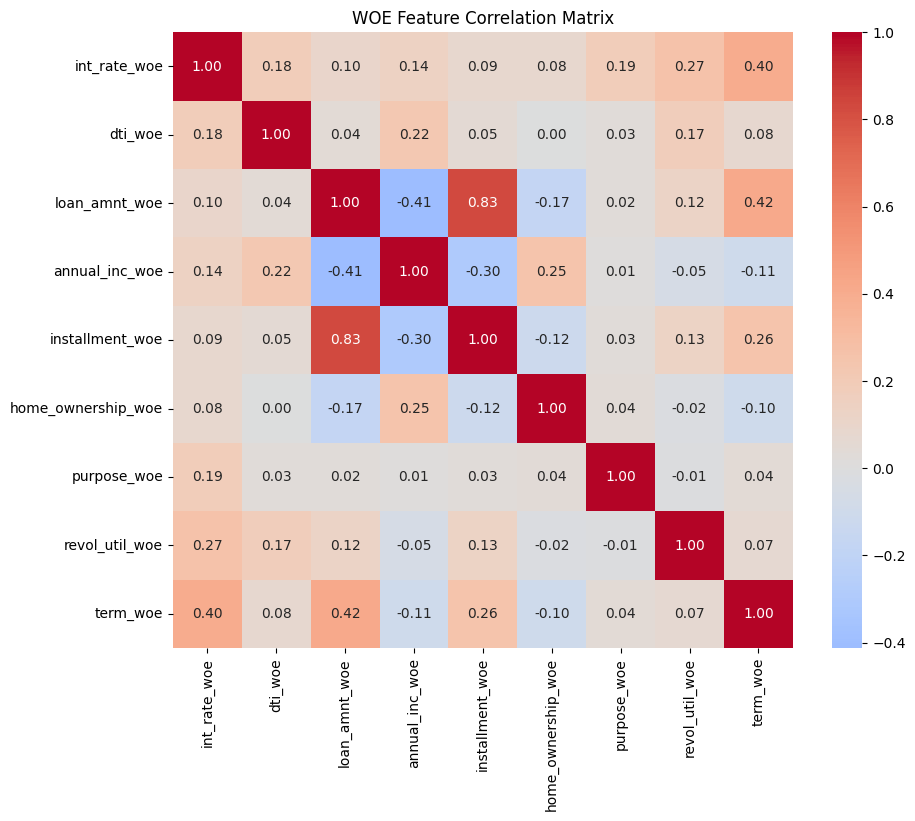

In [27]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))
sns.heatmap(X_train_woe.corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('WOE Feature Correlation Matrix')
plt.show()

In [28]:
final_features = ['int_rate', 'dti', 'loan_amnt', 'annual_inc',
                   'home_ownership', 'purpose', 'revol_util', 'term']

In [29]:
categorical_final = ['home_ownership', 'purpose', 'term']
continuous_final = [f for f in final_features if f not in categorical_final]

woe_tables_final = {}
bin_edges_final = {}
iv_final = {}

for feat in continuous_final:
    table, iv, edges = calc_woe_iv(train, feat, 'default', bins=10, is_categorical=False)
    woe_tables_final[feat] = table
    bin_edges_final[feat] = edges
    iv_final[feat] = iv

for feat in categorical_final:
    table, iv, edges = calc_woe_iv(train, feat, 'default', bins=None, is_categorical=True)
    woe_tables_final[feat] = table
    bin_edges_final[feat] = None
    iv_final[feat] = iv

X_train_woe = build_woe_dataset(train, final_features, categorical_final, woe_tables_final, bin_edges_final)
X_test_woe = build_woe_dataset(test, final_features, categorical_final, woe_tables_final, bin_edges_final)

y_train = train['default']
y_test = test['default']

print(X_train_woe.shape, X_test_woe.shape)

(1108727, 8) (260810, 8)


In [30]:
from sklearn.linear_model import LogisticRegression

model_lr = LogisticRegression()
model_lr.fit(X_train_woe, y_train)

# Check coefficients — in a well-built WOE model, all should be positive
# (since WOE is scaled so that higher WOE = lower risk, higher coefficient = consistent direction)
coef_df = pd.DataFrame({
    'feature': X_train_woe.columns,
    'coefficient': model_lr.coef_[0]
}).sort_values('coefficient', ascending=False)
print(coef_df)

              feature  coefficient
6      revol_util_woe     0.152902
5         purpose_woe    -0.220803
2       loan_amnt_woe    -0.439866
7            term_woe    -0.530050
1             dti_woe    -0.571755
3      annual_inc_woe    -0.656561
0        int_rate_woe    -0.766854
4  home_ownership_woe    -0.954498


In [31]:
print(woe_tables_final['revol_util'][['total', 'bad', 'woe']])

                 total    bad       woe
bin                                    
(-0.001, 20.5]  111606  17176  0.320353
(20.5, 31.3]    110441  19171  0.176431
(31.3, 39.6]    111744  20942  0.082932
(39.6, 47.0]    110340  21761  0.019783
(47.0, 54.0]    111575  22734 -0.021006
(54.0, 60.9]    110038  23099 -0.058575
(60.9, 68.2]    111677  24012 -0.089024
(68.2, 76.1]    109818  23740 -0.095900
(76.1, 85.8]    111289  24450 -0.116567
(85.8, 892.3]   110199  25069 -0.161445


In [32]:
from sklearn.metrics import roc_auc_score

train_probs = model_lr.predict_proba(X_train_woe)[:, 1]
test_probs = model_lr.predict_proba(X_test_woe)[:, 1]

print(f"Train AUC: {roc_auc_score(y_train, train_probs):.4f}")
print(f"Test AUC: {roc_auc_score(y_test, test_probs):.4f}")

Train AUC: 0.7021
Test AUC: 0.6850


In [33]:
from scipy.stats import ks_2samp

ks_stat, p_value = ks_2samp(
    test_probs[y_test == 1],  # predicted probs for actual bad loans
    test_probs[y_test == 0]   # predicted probs for actual good loans
)
print(f"KS statistic: {ks_stat:.4f}")
print(f"p-value: {p_value:.4e}")

KS statistic: 0.2690
p-value: 0.0000e+00


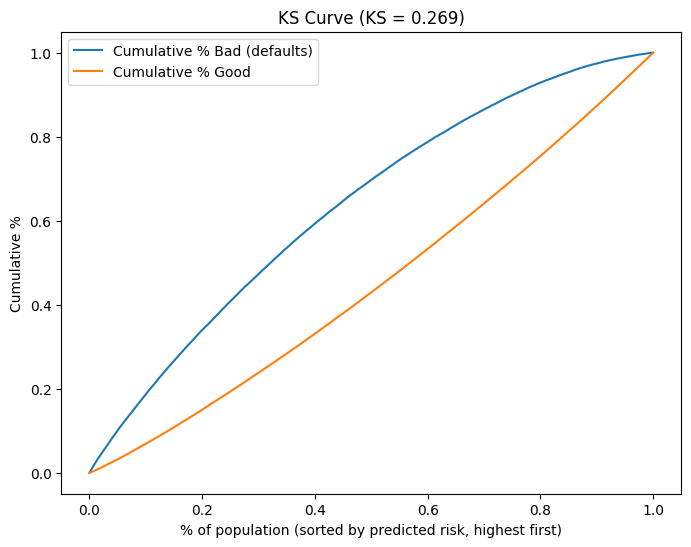

In [34]:
import matplotlib.pyplot as plt

df_ks = pd.DataFrame({'prob': test_probs, 'actual': y_test.values})
df_ks = df_ks.sort_values('prob', ascending=False).reset_index(drop=True)
df_ks['cum_bad'] = df_ks['actual'].cumsum() / df_ks['actual'].sum()
df_ks['cum_good'] = (1 - df_ks['actual']).cumsum() / (1 - df_ks['actual']).sum()
df_ks['pct_pop'] = (df_ks.index + 1) / len(df_ks)

plt.figure(figsize=(8,6))
plt.plot(df_ks['pct_pop'], df_ks['cum_bad'], label='Cumulative % Bad (defaults)')
plt.plot(df_ks['pct_pop'], df_ks['cum_good'], label='Cumulative % Good')
plt.xlabel('% of population (sorted by predicted risk, highest first)')
plt.ylabel('Cumulative %')
plt.title(f'KS Curve (KS = {ks_stat:.3f})')
plt.legend()
plt.show()

In [35]:
gini = 2 * roc_auc_score(y_test, test_probs) - 1
print(f"Gini coefficient: {gini:.4f}")

Gini coefficient: 0.3700


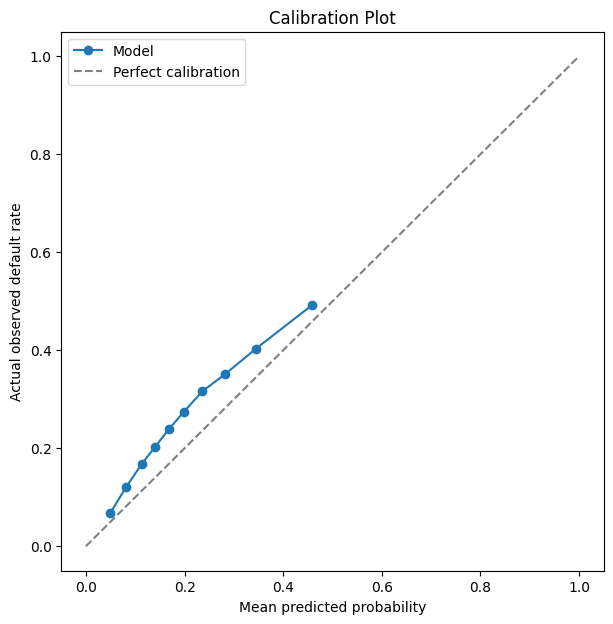

In [36]:
from sklearn.calibration import calibration_curve
import matplotlib.pyplot as plt

prob_true, prob_pred = calibration_curve(y_test, test_probs, n_bins=10, strategy='quantile')

plt.figure(figsize=(7,7))
plt.plot(prob_pred, prob_true, marker='o', label='Model')
plt.plot([0,1], [0,1], linestyle='--', color='gray', label='Perfect calibration')
plt.xlabel('Mean predicted probability')
plt.ylabel('Actual observed default rate')
plt.title('Calibration Plot')
plt.legend()
plt.show()

In [37]:
print("Train default rate:", y_train.mean())
print("Test default rate:", y_test.mean())

Train default rate: 0.2003685307564441
Test default rate: 0.26329511905218356


In [38]:
def calculate_psi(expected, actual, buckets=10):
    breakpoints = np.linspace(0, 100, buckets+1)
    expected_pct = np.percentile(expected, breakpoints)
    expected_pct[0] = -np.inf
    expected_pct[-1] = np.inf

    expected_counts = np.histogram(expected, bins=expected_pct)[0] / len(expected)
    actual_counts = np.histogram(actual, bins=expected_pct)[0] / len(actual)

    expected_counts = np.where(expected_counts == 0, 0.0001, expected_counts)
    actual_counts = np.where(actual_counts == 0, 0.0001, actual_counts)

    psi = np.sum((actual_counts - expected_counts) * np.log(actual_counts / expected_counts))
    return psi

score_psi = calculate_psi(train_probs, test_probs)
print(f"PSI (predicted score distribution, train vs test): {score_psi:.4f}")

PSI (predicted score distribution, train vs test): 0.0075


In [39]:
for feat in continuous_final:
    psi = calculate_psi(train[feat].values, test[feat].values)
    print(f"{feat}: PSI = {psi:.4f}")

int_rate: PSI = 0.0558
dti: PSI = 0.0065
loan_amnt: PSI = 0.0291
annual_inc: PSI = 0.0064
revol_util: PSI = 0.1291


In [40]:
# Standard scorecard scaling parameters (industry convention, e.g. similar to FICO-style scaling)
factor = 20 / np.log(2)      # 20 points to double the odds
offset = 600 - factor * np.log(50)  # anchor: score of 600 at odds of 50:1 (good:bad)

intercept = model_lr.intercept_[0]
coefs = dict(zip(X_train_woe.columns, model_lr.coef_[0]))
n_features = len(coefs)

def build_scorecard(woe_tables, coefs, intercept, n_features, factor, offset):
    scorecard = {}
    for feat_woe_name, coef in coefs.items():
        feat = feat_woe_name.replace('_woe', '')
        table = woe_tables[feat]
        points = -(table['woe'] * coef + intercept / n_features) * factor + offset / n_features
        scorecard[feat] = points
    return scorecard

scorecard = build_scorecard(woe_tables_final, coefs, intercept, n_features, factor, offset)

for feat, points in scorecard.items():
    print(f"\n--- {feat} ---")
    print(points.round(1))


--- int_rate ---
bin
(5.319, 7.49]     100.5
(7.49, 8.9]        87.3
(8.9, 10.49]       78.9
(10.49, 11.53]     72.4
(11.53, 12.79]     69.8
(12.79, 13.98]     65.8
(13.98, 15.1]      61.6
(15.1, 16.99]      57.6
(16.99, 19.05]     51.9
(19.05, 30.99]     43.8
Name: woe, dtype: float64

--- dti ---
bin
(-1.001, 7.39]    72.6
(7.39, 10.57]     71.4
(10.57, 13.08]    69.9
(13.08, 15.37]    68.7
(15.37, 17.64]    67.3
(17.64, 19.98]    66.1
(19.98, 22.57]    64.7
(22.57, 25.62]    63.2
(25.62, 29.67]    61.1
(29.67, 999.0]    57.5
Name: woe, dtype: float64

--- loan_amnt ---
bin
(499.999, 5000.0]     69.4
(5000.0, 7000.0]      69.4
(7000.0, 9000.0]      68.5
(9000.0, 10000.0]     67.1
(10000.0, 12000.0]    65.3
(12000.0, 15000.0]    65.0
(15000.0, 18000.0]    63.7
(18000.0, 21000.0]    64.0
(21000.0, 27500.0]    63.5
(27500.0, 40000.0]    63.4
Name: woe, dtype: float64

--- annual_inc ---
bin
(-0.001, 34000.0]        61.8
(34000.0, 42000.0]       62.6
(42000.0, 50000.0]       63.6
(50000

In [41]:
def score_applicant(row, scorecard, categorical_features):
    total = 0
    for feat, points_table in scorecard.items():
        if feat in categorical_features:
            val = str(row[feat])
            total += points_table.get(val, points_table.mean())  # fallback for unseen category
        else:
            # find which bin this value falls into using saved bin edges
            edges = bin_edges_final[feat]
            binned = pd.cut([row[feat]], bins=edges, include_lowest=True)[0]
            total += points_table.get(binned, points_table.mean())
    return total

In [42]:
def score_from_woe(X_woe, coefs, intercept, n_features, factor, offset):
    score = pd.Series(0.0, index=X_woe.index)
    for feat_woe_name, coef in coefs.items():
        score += -(X_woe[feat_woe_name] * coef + intercept / n_features) * factor + offset / n_features
    return score

test['credit_score'] = score_from_woe(X_test_woe, coefs, intercept, n_features, factor, offset)
train['credit_score'] = score_from_woe(X_train_woe, coefs, intercept, n_features, factor, offset)

print(test['credit_score'].describe())

count    260810.000000
mean        531.017390
std          23.338768
min         463.562123
25%         514.161746
50%         530.442714
75%         546.399262
max         589.736056
Name: credit_score, dtype: float64


In [43]:
# Rescale: target mean=600, std=100 (a more typical, spread-out scorecard range)
target_mean = 600
target_std = 100

current_mean = test['credit_score'].mean()
current_std = test['credit_score'].std()

def rescale_score(score, current_mean, current_std, target_mean, target_std):
    return target_mean + (score - current_mean) / current_std * target_std

test['credit_score_scaled'] = rescale_score(test['credit_score'], current_mean, current_std, target_mean, target_std)
train['credit_score_scaled'] = rescale_score(train['credit_score'], current_mean, current_std, target_mean, target_std)

print(test['credit_score_scaled'].describe())

count    260810.000000
mean        600.000000
std         100.000000
min         310.973323
25%         527.778351
50%         597.537677
75%         665.906957
max         851.592823
Name: credit_score_scaled, dtype: float64


In [44]:
final_features = ['int_rate', 'dti', 'loan_amnt', 'annual_inc',
                   'home_ownership', 'purpose', 'term']

categorical_final = ['home_ownership', 'purpose', 'term']
continuous_final = [f for f in final_features if f not in categorical_final]

woe_tables_final = {}
bin_edges_final = {}
iv_final = {}

for feat in continuous_final:
    table, iv, edges = calc_woe_iv(train, feat, 'default', bins=10, is_categorical=False)
    woe_tables_final[feat] = table
    bin_edges_final[feat] = edges
    iv_final[feat] = iv

for feat in categorical_final:
    table, iv, edges = calc_woe_iv(train, feat, 'default', bins=None, is_categorical=True)
    woe_tables_final[feat] = table
    bin_edges_final[feat] = None
    iv_final[feat] = iv

X_train_woe = build_woe_dataset(train, final_features, categorical_final, woe_tables_final, bin_edges_final)
X_test_woe = build_woe_dataset(test, final_features, categorical_final, woe_tables_final, bin_edges_final)

y_train = train['default']
y_test = test['default']

In [45]:
model_lr = LogisticRegression()
model_lr.fit(X_train_woe, y_train)

coef_df = pd.DataFrame({
    'feature': X_train_woe.columns,
    'coefficient': model_lr.coef_[0]
}).sort_values('coefficient')
print(coef_df)

train_probs = model_lr.predict_proba(X_train_woe)[:, 1]
test_probs = model_lr.predict_proba(X_test_woe)[:, 1]

print(f"Train AUC: {roc_auc_score(y_train, train_probs):.4f}")
print(f"Test AUC: {roc_auc_score(y_test, test_probs):.4f}")

ks_stat, _ = ks_2samp(test_probs[y_test==1], test_probs[y_test==0])
print(f"KS: {ks_stat:.4f}")

              feature  coefficient
4  home_ownership_woe    -0.957254
0        int_rate_woe    -0.759403
3      annual_inc_woe    -0.666179
1             dti_woe    -0.561758
6            term_woe    -0.534652
2       loan_amnt_woe    -0.429862
5         purpose_woe    -0.230112
Train AUC: 0.7020
Test AUC: 0.6857
KS: 0.2699


In [46]:
intercept = model_lr.intercept_[0]
coefs = dict(zip(X_train_woe.columns, model_lr.coef_[0]))
n_features = len(coefs)

factor = 20 / np.log(2)
offset = 600 - factor * np.log(50)

scorecard = build_scorecard(woe_tables_final, coefs, intercept, n_features, factor, offset)

train['credit_score'] = score_from_woe(X_train_woe, coefs, intercept, n_features, factor, offset)
test['credit_score'] = score_from_woe(X_test_woe, coefs, intercept, n_features, factor, offset)

target_mean, target_std = 600, 100
current_mean, current_std = train['credit_score'].mean(), train['credit_score'].std()

train['credit_score_scaled'] = rescale_score(train['credit_score'], current_mean, current_std, target_mean, target_std)
test['credit_score_scaled'] = rescale_score(test['credit_score'], current_mean, current_std, target_mean, target_std)

print(test['credit_score_scaled'].describe())

count    260810.000000
mean        596.771689
std         103.381481
min         301.778607
25%         522.167876
50%         593.975330
75%         664.568111
max         854.615906
Name: credit_score_scaled, dtype: float64


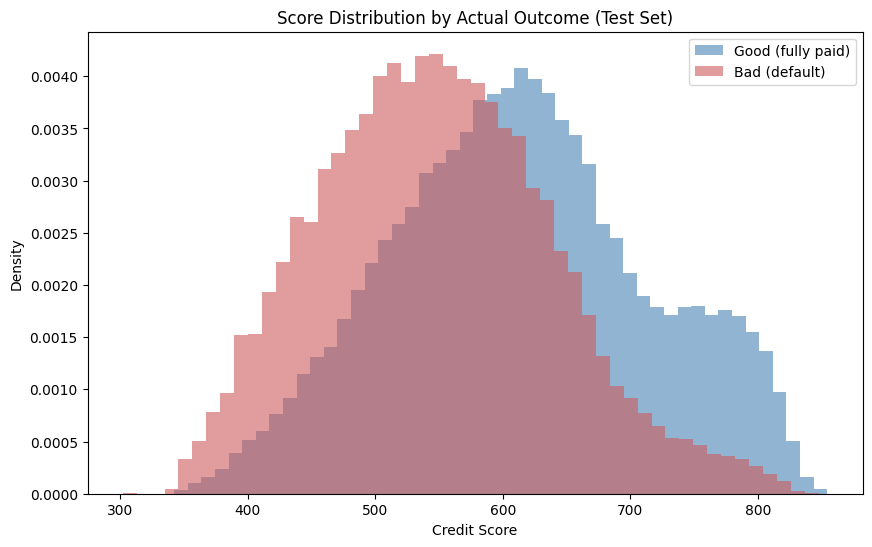

In [47]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.hist(test.loc[y_test==0, 'credit_score_scaled'], bins=50, alpha=0.6, label='Good (fully paid)', color='steelblue', density=True)
plt.hist(test.loc[y_test==1, 'credit_score_scaled'], bins=50, alpha=0.6, label='Bad (default)', color='indianred', density=True)
plt.xlabel('Credit Score')
plt.ylabel('Density')
plt.title('Score Distribution by Actual Outcome (Test Set)')
plt.legend()
plt.show()

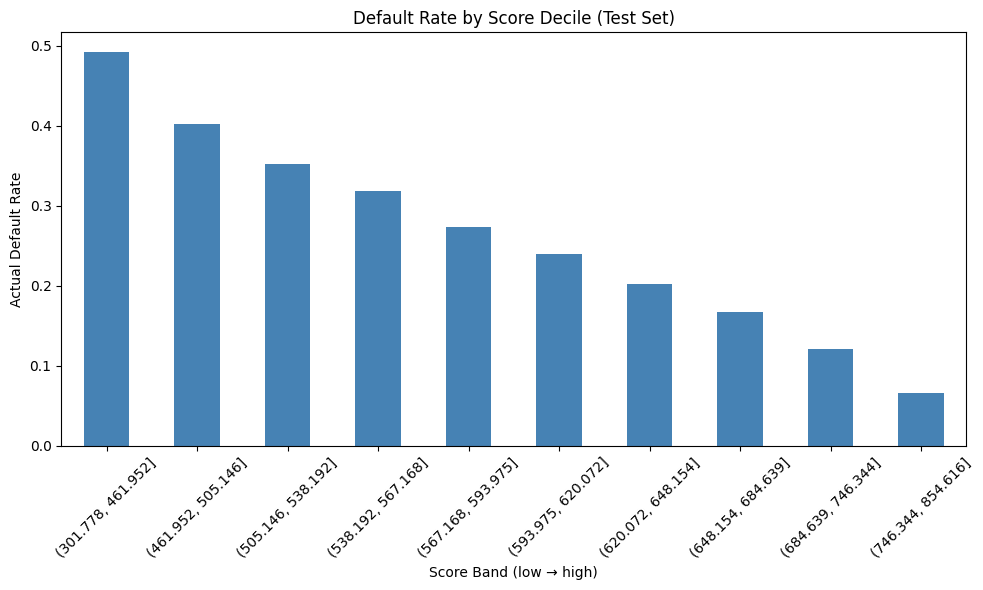

In [48]:
test['score_band'] = pd.qcut(test['credit_score_scaled'], 10, duplicates='drop')
band_default = test.groupby('score_band', observed=True)['default'].mean().sort_index()

plt.figure(figsize=(10, 6))
band_default.plot(kind='bar', color='steelblue')
plt.ylabel('Actual Default Rate')
plt.xlabel('Score Band (low → high)')
plt.title('Default Rate by Score Decile (Test Set)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()